## packages

In [1]:
from datetime import datetime
from datetime import timedelta
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
import warnings
from dateutil.relativedelta import relativedelta
from dateutil import parser
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

## data prep

In [2]:
# Function call to process the tradewed data file
def data_preprocess(filepath):
    rawdata = pd.read_csv(filepath)
    rawdata = rawdata.loc[rawdata['ACCEPTEDVOL'] != 0] # Ignore trade stamps with zero volume
    # Remove BILLs , STRIPs and TRSY FRN data to skip the computation from yield to price for Bills and negative spreads for Strips + Treasury FRN
    substring = 'Bill'
    substring2 = 'Strip'
    substring3 = 'TRSY FRN'
    filter = rawdata['MATURITY_RANGE'].str.contains(substring)
    rawdata = rawdata[~filter]
    filter2 = rawdata['MATURITY_RANGE'].str.contains(substring2)
    rawdata = rawdata[~filter2]
    filter3 = rawdata['MATURITY_RANGE'].str.contains(substring3)
    rawdata = rawdata[~filter3]
    rawdata = rawdata.loc[rawdata['TRADETYPE'] == 'OUTRIGHT'] # Only consider outright trades
    rawdata.reset_index(inplace=True)
    # Convert TRADETIME , MATURITY DATE and TRADE DATE to datetime and assign new index
    tradetime = []
    tradedate = []
    maturitydate = []
    for i in range(rawdata.shape[0]):
        tradetime.append(datetime.datetime.strptime(rawdata['TRADETIME'].iloc[i].rstrip(' Z'), "%Y-%m-%d %H:%M:%S.%f"))
        tradedate.append(datetime.datetime.strptime(rawdata['TRADEDATE'].iloc[i], '%m/%d/%y'))
        maturitydate.append(datetime.datetime.strptime(rawdata['MATURITY_DATE'].iloc[i], '%m/%d/%y'))
    rawdata['TIMESTAMP'] = tradetime
    rawdata['TRADEDATE'] = tradedate
    rawdata['MATURITY_DATE'] = maturitydate
    rawdata.set_index('TIMESTAMP', inplace= True)
    rawdata.sort_index(inplace=True)
    return rawdata

In [3]:
tw1 = data_preprocess('Blockhouse Data 1.csv')
tw2 = data_preprocess('Blockhouse Data 2.csv')
tw3 = data_preprocess('Blockhouse Data 3.csv')
tw4 = data_preprocess('Blockhouse Data 4.csv')
rawdata = pd.concat([tw1, tw2, tw3, tw4], axis =0)

In [4]:
rawdata.columns

Index(['index', 'TRADEDATE', 'DEALER', 'DEALERCOUNT', 'ACCEPTED',
       'SEEN_INQUIRY', 'ACCEPTEDVOL', 'SEENVOLUME', 'PRICE', 'TRADETIME',
       'INSTRUMENT', 'INSTRUMENT_DESC', 'MATURITY_DATE', 'MATURITY_RANGE',
       'COUPON_RATE', 'SIDE', 'COMP_ASK', 'COMP_BID', 'PROTOCOL', 'TRADETYPE',
       'SOURCE'],
      dtype='object')

In [5]:
rawdata.head(5)

,index,TRADEDATE,DEALER,DEALERCOUNT,ACCEPTED,SEEN_INQUIRY,ACCEPTEDVOL,SEENVOLUME,PRICE,TRADETIME,...,INSTRUMENT_DESC,MATURITY_DATE,MATURITY_RANGE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,PROTOCOL,TRADETYPE,SOURCE
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-10-02 06:47:43,47059,2023-10-02,D69,5,1,1,1100.90,1100.90,99.761887,2023-10-02 06:47:43.000 Z,...,"T 4 5/8 <MD2Y,2462045> 5yr",2028-09-30,Note 3.5 - 5.5 Year,4.625,BUY,99.769531,99.753906,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,19829,2023-10-02,D38,5,1,1,3939.00,3939.00,99.691574,2023-10-02 06:47:43.000 Z,...,"T 5 <MD2Y,2460919>",2025-08-31,Note 1.5 - 3.5 Year,5.000,BUY,99.703125,99.691406,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,50786,2023-10-02,D28,5,1,1,297.95,297.95,89.461106,2023-10-02 06:47:43.000 Z,...,"T 1 1/8 <MD2Y,2461345>",2026-10-31,Note 1.5 - 3.5 Year,1.125,BUY,89.488281,89.433594,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,24582,2023-10-02,D38,5,1,1,676.70,676.70,90.133013,2023-10-02 06:47:43.000 Z,...,"T 4 1/8 <MD2Y,2471130> 30yr",2053-08-15,Note >10 Year,4.125,BUY,90.160156,90.128906,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,57986,2023-10-02,D11,5,1,1,176.75,176.75,60.906450,2023-10-02 06:47:43.000 Z,...,"T 2 1/4 <MD2Y,2470583>",2052-02-15,Note >10 Year,2.250,BUY,60.960938,60.882812,REG List,OUTRIGHT,TW


In [6]:
filtered_rawdata = rawdata[['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE','MATURITY_DATE', 'TRADEDATE',"COUPON_RATE",'SIDE','COMP_ASK','COMP_BID']].copy()
filtered_rawdata.head()

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID
TIMESTAMP,,,,,,,,,,,
2023-10-02 06:47:43,D69,1100.90,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906
2023-10-02 06:47:43,D38,3939.00,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406
2023-10-02 06:47:43,D28,297.95,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594
2023-10-02 06:47:43,D38,676.70,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906
2023-10-02 06:47:43,D11,176.75,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812


In [7]:
filtered_rawdata.shape

(50741, 11)

In [8]:
filtered_rawdata['SIGN'] = filtered_rawdata['SIDE'].apply(lambda x: 1 if x == 'BUY' else -1)
filtered_rawdata['ACCEPTEDVOL'] = filtered_rawdata['ACCEPTEDVOL'] * 10
filtered_rawdata['SIGNED_VOLUME'] = filtered_rawdata['ACCEPTEDVOL'] * filtered_rawdata['SIGN']
filtered_rawdata

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME
TIMESTAMP,,,,,,,,,,,,,
2023-10-02 06:47:43,D69,11009.0,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906,1,11009.0
2023-10-02 06:47:43,D38,39390.0,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0
2023-10-02 06:47:43,D28,2979.5,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5
2023-10-02 06:47:43,D38,6767.0,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906,1,6767.0
2023-10-02 06:47:43,D11,1767.5,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812,1,1767.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:46,D50,202000.0,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,97.585938,-1,-202000.0
2023-12-29 13:51:46,D50,121200.0,95.769699,9128284V9,Note 3.5 - 5.5 Year,2028-08-15,2023-12-29,2.875,BUY,95.820312,95.726562,1,121200.0
2023-12-29 13:51:46,D28,252500.0,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,97.542969,-1,-252500.0


In [9]:
# Calculate years to maturity
ytm = []
for i in range(0,rawdata.shape[0]):
    ytm.append(relativedelta(filtered_rawdata['MATURITY_DATE'].iloc[i],filtered_rawdata['TRADEDATE'].iloc[i]).years)
filtered_rawdata['Years to Maturity'] = ytm
# calculate spreads
filtered_rawdata['Spread'] = (filtered_rawdata['COMP_ASK'] - filtered_rawdata['COMP_BID'])/2

In [10]:
filtered_rawdata['MATURITY_RANGE'].unique()

array(['Note 3.5 - 5.5 Year', 'Note 1.5 - 3.5 Year', 'Note >10 Year',
       'Note 5.5 - 10 Year', 'Note 0 - 1.5 Year', 'TIPS 0 - 5 year',
       'TIPS 5 - 10 year', 'TIPS > 10 year'], dtype=object)

In [11]:
filtered_rawdata

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME,Years to Maturity,Spread
TIMESTAMP,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D69,11009.0,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906,1,11009.0,4,0.007812
2023-10-02 06:47:43,D38,39390.0,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0,1,0.005859
2023-10-02 06:47:43,D28,2979.5,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5,3,0.027344
2023-10-02 06:47:43,D38,6767.0,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906,1,6767.0,29,0.015625
2023-10-02 06:47:43,D11,1767.5,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812,1,1767.5,28,0.039062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:46,D50,202000.0,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,97.585938,-1,-202000.0,0,0.027344
2023-12-29 13:51:46,D50,121200.0,95.769699,9128284V9,Note 3.5 - 5.5 Year,2028-08-15,2023-12-29,2.875,BUY,95.820312,95.726562,1,121200.0,4,0.046875
2023-12-29 13:51:46,D28,252500.0,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,97.542969,-1,-252500.0,1,0.031250


## Parameter for OW Model: daily_vol, adv, beta, qt, I_t, v_t, lambda

In [12]:
filtered_rawdata.MATURITY_RANGE.value_counts()

MATURITY_RANGE
Note 1.5 - 3.5 Year    12244
Note 0 - 1.5 Year       9955
Note >10 Year           8946
Note 5.5 - 10 Year      8760
Note 3.5 - 5.5 Year     7661
TIPS 0 - 5 year         1620
TIPS > 10 year           782
TIPS 5 - 10 year         773
Name: count, dtype: int64

### select one maturity data

In [13]:
group1 = filtered_rawdata[filtered_rawdata['MATURITY_RANGE'] == 'Note 1.5 - 3.5 Year']
group1

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME,Years to Maturity,Spread
TIMESTAMP,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D38,39390.0,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0,1,0.005859
2023-10-02 06:47:43,D28,2979.5,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5,3,0.027344
2023-10-02 06:50:42,D38,13231.0,97.109543,91282CGV7,Note 1.5 - 3.5 Year,2026-04-15,2023-10-02,3.750,BUY,97.125000,97.101562,1,13231.0,2,0.011719
2023-10-02 07:46:44,D7,20200.0,99.351731,91282CHY0,Note 1.5 - 3.5 Year,2026-09-15,2023-10-02,4.625,BUY,99.367188,99.351562,1,20200.0,2,0.007812
2023-10-02 08:22:38,D74,2020.0,96.214676,91282CEU1,Note 1.5 - 3.5 Year,2025-06-15,2023-10-02,2.875,SELL,96.238281,96.199219,-1,-2020.0,1,0.019531
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:50:21,D28,80800.0,100.968918,91282CHM6,Note 1.5 - 3.5 Year,2026-07-15,2023-12-29,4.500,BUY,100.984375,100.953125,1,80800.0,2,0.015625
2023-12-29 13:50:21,D38,80800.0,101.523606,91282CJC6,Note 1.5 - 3.5 Year,2026-10-15,2023-12-29,4.625,BUY,101.539062,101.515625,1,80800.0,2,0.011719
2023-12-29 13:50:21,D74,141400.0,101.414231,91282CHY0,Note 1.5 - 3.5 Year,2026-09-15,2023-12-29,4.625,BUY,101.437500,101.414062,1,141400.0,2,0.011719


In [14]:
group1['TRADEDATE'] = pd.to_datetime(group1['TRADEDATE'])

# Group by 'TRADEDATE' and calculate the daily volatility as the standard deviation of 'PRICE'
daily_volatility = group1.groupby('TRADEDATE')['PRICE'].std()

# Map the daily volatility back to the original DataFrame
group1['Daily_Volatility'] = group1['TRADEDATE'].map(daily_volatility)

### daily volatility

In [15]:
group1.Daily_Volatility

TIMESTAMP
2023-10-02 06:47:43    3.636997
2023-10-02 06:47:43    3.636997
2023-10-02 06:50:42    3.636997
2023-10-02 07:46:44    3.636997
2023-10-02 08:22:38    3.636997
                         ...   
2023-12-29 13:50:21    3.605377
2023-12-29 13:50:21    3.605377
2023-12-29 13:50:21    3.605377
2023-12-29 13:51:07    3.605377
2023-12-29 13:51:07    3.605377
Name: Daily_Volatility, Length: 12244, dtype: float64

### ADV: average daily volume

In [16]:
def calculate_monthly_adv_separately(data):
    # resample volume to daily
    daily_vol = data['ACCEPTEDVOL'].resample('D').sum()
    print("Daily Total Volume:\n", daily_vol.head(10))

    october_total_vol = daily_vol[0]  # total volume for October
    december_total_vol = daily_vol[2]  # total volume for December
    # Calculate the number of trading days for October and December
    october_trading_days = data['ACCEPTEDVOL']['2023-10'].count()
    december_trading_days = data['ACCEPTEDVOL']['2023-12'].count()

    # Calculate ADV
    october_adv = october_total_vol / october_trading_days
    december_adv = december_total_vol / december_trading_days

    # Assign the ADV value
    data.loc['2023-10', 'ADV'] = october_adv
    data.loc['2023-12', 'ADV'] = december_adv

    # Forward fill for consistency
    data['ADV'].fillna(method='ffill', inplace=True)
    data['ADV'].fillna(method='bfill', inplace=True)

    return data[['ADV']], october_total_vol, december_total_vol

In [17]:
group1[['ADV']], october_total_vol, december_total_vol = calculate_monthly_adv_separately(group1)

Daily Total Volume:
 TIMESTAMP
2023-10-02    2029226.35
2023-10-03    2300066.94
2023-10-04    1177301.45
2023-10-05    1162227.20
2023-10-06    2131342.40
2023-10-07          0.00
2023-10-08          0.00
2023-10-09          0.00
2023-10-10    4103338.11
2023-10-11    1181639.40
Freq: D, Name: ACCEPTEDVOL, dtype: float64


In [18]:
group1.ADV

TIMESTAMP
2023-10-02 06:47:43    380.218540
2023-10-02 06:47:43    380.218540
2023-10-02 06:50:42    380.218540
2023-10-02 07:46:44    380.218540
2023-10-02 08:22:38    380.218540
                          ...    
2023-12-29 13:50:21    170.450478
2023-12-29 13:50:21    170.450478
2023-12-29 13:50:21    170.450478
2023-12-29 13:51:07    170.450478
2023-12-29 13:51:07    170.450478
Name: ADV, Length: 12244, dtype: float64

In [19]:
print('OCT',october_total_vol)
print('DEC',december_total_vol)

OCT 2029226.35
DEC 1177301.45


### beta

In [20]:
import math
beta = math.log(2)/1 # half-life is 30min, bin is 60 min
print('beta:',beta)

beta: 0.6931471805599453


### qt: quanity/volume in each bin (set bin 60min here)

In [21]:
def add_resampled_volume(df):
    result_df = df.copy()
    bin = result_df.index.floor('60T')
    # Calculate qt for each 60-minute window
    qt = (result_df.groupby(bin)['SIGNED_VOLUME']
                .transform('sum'))
    result_df['qt'] = qt

    return result_df

In [22]:
group1['SIGN'].unique()

array([ 1, -1])

In [23]:
group1 = add_resampled_volume(group1)
qt = group1['SIGNED_VOLUME'].resample('60T').sum()

# Compare results
print(group1[['SIGNED_VOLUME', 'qt']])
print(qt)

                     SIGNED_VOLUME          qt
TIMESTAMP                                     
2023-10-02 06:47:43        39390.0     55600.5
2023-10-02 06:47:43         2979.5     55600.5
2023-10-02 06:50:42        13231.0     55600.5
2023-10-02 07:46:44        20200.0     20200.0
2023-10-02 08:22:38        -2020.0     12776.5
...                            ...         ...
2023-12-29 13:50:21        80800.0  10631411.5
2023-12-29 13:50:21        80800.0  10631411.5
2023-12-29 13:50:21       141400.0  10631411.5
2023-12-29 13:51:07        20200.0  10631411.5
2023-12-29 13:51:07        20200.0  10631411.5

[12244 rows x 2 columns]
TIMESTAMP
2023-10-02 06:00:00       55600.50
2023-10-02 07:00:00       20200.00
2023-10-02 08:00:00       12776.50
2023-10-02 09:00:00       45106.60
2023-10-02 10:00:00      385991.70
                          ...     
2023-12-29 09:00:00      172260.55
2023-12-29 10:00:00     4229462.87
2023-12-29 11:00:00     -788880.70
2023-12-29 12:00:00     7086503.40
202

In [24]:
# check for missing values
(group1.qt == 0).value_counts()

qt
False    12244
Name: count, dtype: int64

### func to find lambda
Lambda is the hyperparameter of the OW model, we should select lambda with the highest R2

In [25]:
import numpy as np
import math
from sklearn.linear_model import LinearRegression

def calculate_impact_and_liquidity(data, h_minutes, delta_t=1/24):  # h in minutes, delta_t still in hours
    """
    Calculate impact state I_t and market activity v_t using half-life transformation
    h_minutes: time interval for return horizon (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()

    # Convert h from minutes to hours for beta calculation
    h_hours = h_minutes / 60

    # Calculate beta using half-life transformation
    beta = math.log(2) / h_hours

    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))

    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Exponential moving average with same half-life
    decay_factor = np.exp(-beta * delta_t)  # Using delta_t for decay

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]

        # Update market activity using exponential moving average
        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)

        # Calculate impact state with flow effects and impact decay
        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)  # Using delta_t for decay
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))  # Flow effects
        else:
            I_values[i] = I_values[i-1]

    data['I_t'] = I_values
    data['v_t'] = v_values
    return data, beta

def estimate_lambda(data, initial_lambda, h_minutes, delta_t=1/24):
    """
    Estimate optimal lambda for a given time interval h_minutes
    h_minutes: horizon for returns (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    # Calculate impact states
    impact_data, beta = calculate_impact_and_liquidity(data, h_minutes, delta_t)

    # Calculate returns using h periods
    h_periods = int(len(impact_data) * (h_minutes/(24*60)))  # Convert minutes to fraction of day
    h_periods = max(1, h_periods)  # Ensure at least 1 period

    # Calculate Δ^h P = (P_{t+h} - P_t)/P_t using h as the horizon
    impact_data['Delta_h_P'] = (impact_data['PRICE'].shift(-h_periods) - impact_data['PRICE']) / impact_data['PRICE']

    # Calculate Δ^h I = I_{t+h} - I_t using h as the horizon
    impact_data['Delta_h_I'] = impact_data['I_t'].shift(-h_periods) - impact_data['I_t']

    # Remove NaN values
    impact_data.dropna(inplace=True)

    # Run regression: Δ^h P = Δ^h I(λ) + ϵ
    X = impact_data[['Delta_h_I']]
    y = impact_data['Delta_h_P']

    model = LinearRegression()
    model.fit(X, y)

    optimal_lambda = model.coef_[0]
    r_squared = model.score(X, y)

    return optimal_lambda, r_squared, beta, impact_data

def grid_search_lambda(data, h_values_minutes, delta_t=1/24):
    """
    Test different time intervals to find optimal lambda
    """
    results = []
    for h_minutes in h_values_minutes:
        optimal_lambda, r_squared, beta, _ = estimate_lambda(data, 1.0, h_minutes, delta_t)
        results.append({
            'h_minutes': h_minutes,
            'h_hours': h_minutes/60,
            'h_periods': max(1, int(len(data) * (h_minutes/(24*60)))),
            'beta': beta,
            'lambda': optimal_lambda,
            'r_squared': r_squared
        })
    return results

In [26]:
h_values_minutes = [6, 12, 18, 24, 30, 48, 60, 90, 120]  # horizons in minutes
delta_t = 1/24  # 1 hour for impact decay
results = grid_search_lambda(group1, h_values_minutes, delta_t)

def print_results(results):
    print("\nSummary of Results:")
    print("-" * 80)
    print(f"{'h (min)':>10} {'beta':>12} {'lambda':>12} {'R²':>12}")
    print("-" * 80)

    for result in results:
        h_min = result['h_minutes']
        beta = result['beta']
        lambda_val = result['lambda']
        r2 = result['r_squared']

        print(f"{h_min:10.1f} {beta:12.6f} {lambda_val:12.6f} {r2:12.6f}")
    print("-" * 80)

# After running grid_search_lambda, use:
results = grid_search_lambda(group1, h_values_minutes, delta_t)
print_results(results)


Summary of Results:
--------------------------------------------------------------------------------
   h (min)         beta       lambda           R²
--------------------------------------------------------------------------------
       6.0     6.931472     0.000020     0.002903
      12.0     3.465736     0.000012     0.002805
      18.0     2.310491     0.000008     0.002196
      24.0     1.732868     0.000006     0.002152
      30.0     1.386294     0.000006     0.002449
      48.0     0.866434     0.000002     0.000931
      60.0     0.693147     0.000003     0.003058
      90.0     0.462098     0.000002     0.001335
     120.0     0.346574     0.000002     0.003898
--------------------------------------------------------------------------------


## Reduced OW Model

set $\lambda = 0.000002$, since the R2 is the largest here

Then fill the result back to calculate the price impact (I_t) at each state

In [27]:
def ow(data, h_minutes, delta_t=1/24):  # h in minutes, delta_t still in hours
    """
    Calculate impact state I_t and market activity v_t using half-life transformation
    h_minutes: time interval for return horizon (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()

    # Convert h from minutes to hours for beta calculation
    h_hours = h_minutes / 60

    # Calculate beta using half-life transformation
    beta = math.log(2) / h_hours

    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))

    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Exponential moving average with same half-life
    decay_factor = np.exp(-beta * delta_t)  # Using delta_t for decay

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]

        # Update market activity using exponential moving average
        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)

        # Calculate impact state with flow effects and impact decay
        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)  # Using delta_t for decay
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))  # Flow effects
        else:
            I_values[i] = I_values[i-1]

    data['I_t'] = I_values/10
    data['v_t'] = v_values
    return data

In [28]:
df_it = ow(group1, h_minutes=120, delta_t=1/24)

### figure

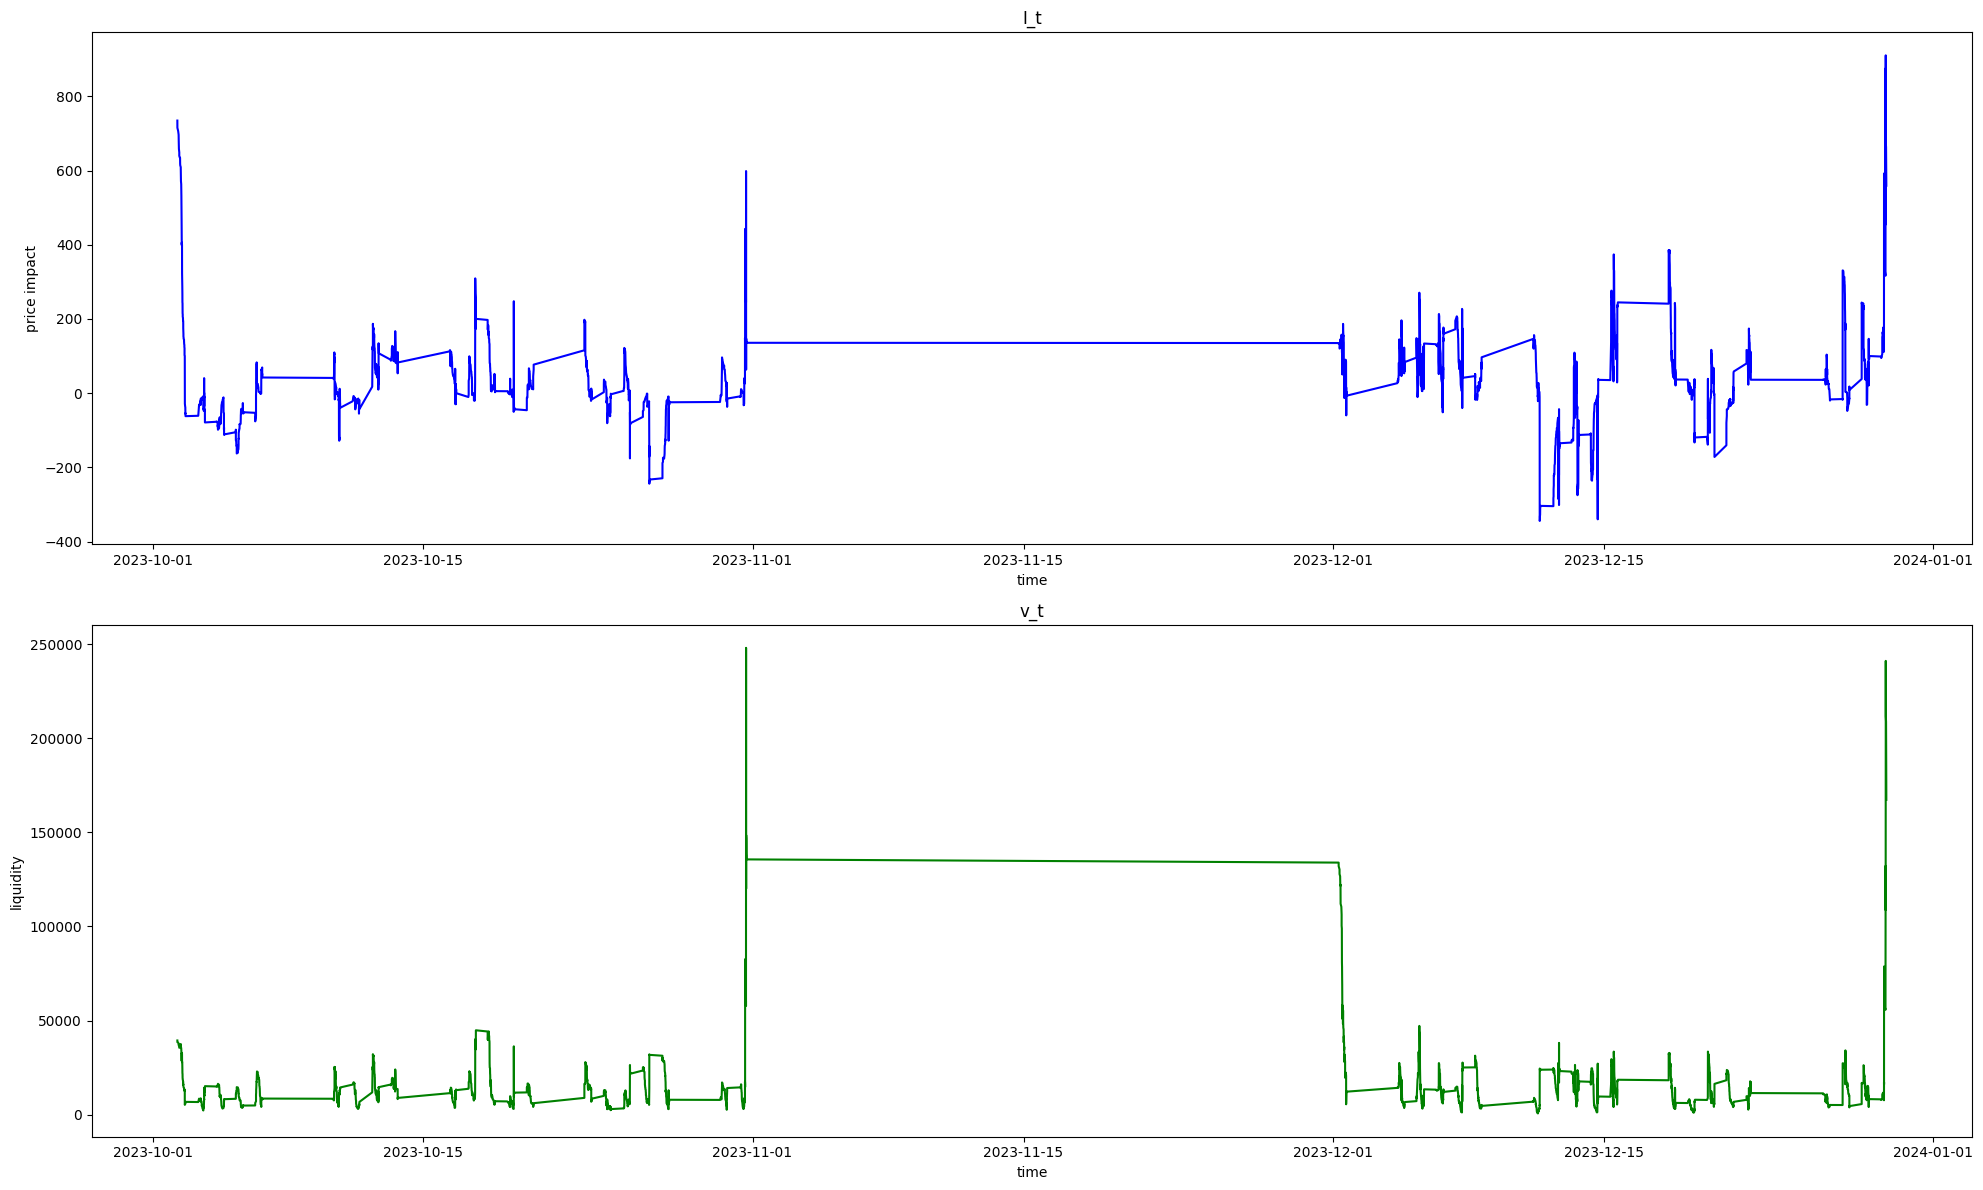

In [442]:
plt.figure(figsize=(20, 12))

# First subplot for df_it.I_t
plt.subplot(2, 1, 1)
plt.plot(df_it.I_t, color='blue')
plt.xlabel('time')
plt.ylabel('price impact')
plt.title('I_t')

# Second subplot for df_it.v_t
plt.subplot(2, 1, 2)
plt.plot(df_it.v_t, color='green')
plt.xlabel('time')
plt.ylabel('liquidity')
plt.title('v_t')

plt.tight_layout()
plt.show()


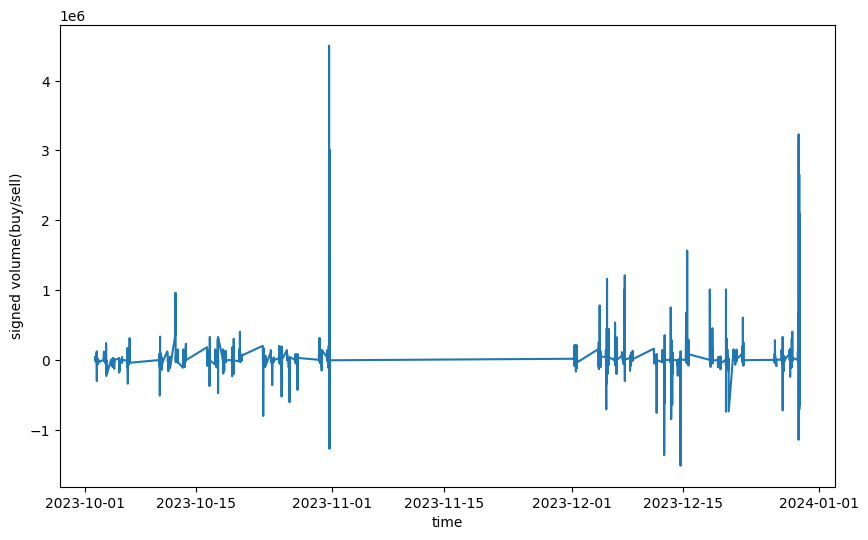

In [443]:
plt.figure(figsize=(10,6))
plt.plot(df_it.SIGNED_VOLUME)
plt.xlabel('time')
plt.ylabel('signed volume(buy/sell)')
plt.show()

# Find the optimal volume

In [29]:
import numpy as np
import math

def ow_with_optimal_volume(data, h_minutes, delta_t=1/24, target_impact=500):
    """
    Calculate impact state I_t, market activity v_t, and optimal trading volume Q_t.

    h_minutes: Time interval for return horizon (in minutes)
    delta_t: Time step for impact decay (in hours)
    target_impact: Desired target impact level (e.g., 50-60 bps)
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()

    # Convert h from minutes to hours for beta calculation
    h_hours = h_minutes / 60

    # Calculate beta using half-life transformation
    beta = math.log(2) / h_hours

    # Initialize arrays for impact (I_t), liquidity (v_t), and optimal volume (Q_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))
    optimal_Q_values = np.full(len(data), np.nan)  # Placeholder for optimal trading volume

    # Initial values for I_t and v_t
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Exponential moving average with same half-life
    decay_factor = np.exp(-beta * delta_t)  # Using delta_t for decay

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]

        # Update market activity using exponential moving average
        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)

        # Calculate impact state with flow effects and impact decay
        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)  # Using delta_t for decay
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))  # Flow effects

            # Calculate optimal Q_t based on the target impact
            Q_t = (target_impact - I_values[i] * (1 - beta * delta_t)) * np.sqrt(adv * v_values[i]) / sigma
            optimal_Q_values[i] = Q_t
        else:
            I_values[i] = I_values[i-1]  # Carry forward the previous impact state if ADV or v_t is zero

    # Assign calculated arrays back to the DataFrame
    data['I_t'] = I_values/10
    data['v_t'] = v_values
    data['Optimal_Q_t'] = abs(optimal_Q_values)

    return data

In [30]:
df_it = ow_with_optimal_volume(group1, h_minutes=120, delta_t=1/24)

In [31]:
df_it

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,...,SIGNED_VOLUME,Years to Maturity,Spread,Daily_Volatility,ADV,qt,ABS_VOLUME,I_t,v_t,Optimal_Q_t
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D38,39390.0,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,...,39390.0,1,0.005859,3.636997,380.218540,55600.5,39390.0,734.703766,39390.000000,NaN
2023-10-02 06:47:43,D28,2979.5,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,...,2979.5,3,0.027344,3.636997,380.218540,55600.5,2979.5,724.376113,38867.989894,7.017505e+06
2023-10-02 06:50:42,D38,13231.0,97.109543,91282CGV7,Note 1.5 - 3.5 Year,2026-04-15,2023-10-02,3.750,BUY,97.125000,...,13231.0,2,0.011719,3.636997,380.218540,55600.5,13231.0,715.173438,38500.437463,6.888833e+06
2023-10-02 07:46:44,D7,20200.0,99.351731,91282CHY0,Note 1.5 - 3.5 Year,2026-09-15,2023-10-02,4.625,BUY,99.367188,...,20200.0,2,0.007812,3.636997,380.218540,20200.0,20200.0,706.772698,38238.067726,6.778520e+06
2023-10-02 08:22:38,D74,2020.0,96.214676,91282CEU1,Note 1.5 - 3.5 Year,2025-06-15,2023-10-02,2.875,SELL,96.238281,...,-2020.0,1,0.019531,3.636997,380.218540,12776.5,2020.0,696.372502,37718.816483,6.625611e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:50:21,D28,80800.0,100.968918,91282CHM6,Note 1.5 - 3.5 Year,2026-07-15,2023-12-29,4.500,BUY,100.984375,...,80800.0,2,0.015625,3.605377,170.450478,10631411.5,80800.0,574.615759,173299.800260,7.783318e+06
2023-12-29 13:50:21,D38,80800.0,101.523606,91282CJC6,Note 1.5 - 3.5 Year,2026-10-15,2023-12-29,4.625,BUY,101.539062,...,80800.0,2,0.011719,3.605377,170.450478,10631411.5,80800.0,571.698597,171973.648998,7.710306e+06
2023-12-29 13:50:21,D74,141400.0,101.414231,91282CHY0,Note 1.5 - 3.5 Year,2026-09-15,2023-12-29,4.625,BUY,101.437500,...,141400.0,2,0.011719,3.605377,170.450478,10631411.5,141400.0,572.871045,171535.320666,7.717804e+06


In [32]:
# Calculate Slippage
group1['MID'] = (group1['COMP_BID'] + group1['COMP_ASK']) / 2

# Define slippage calculation function in bps
def calculate_slippage(row):
    if row['SIDE'] == 'BUY':
        return (row['PRICE'] - row['MID'])/row['MID'] * 10000 # Buy side slippage in bps; if in $: row['PRICE'] - row['MID']
    elif row['SIDE'] == 'SELL':
        return (row['MID'] - row['PRICE'])/row['MID'] * 10000 # Sell side slippage in bps; if in $: row['MID'] - row['PRICE']
    return None

def calculate_slippage_dollars(row):
    if row['SIDE'] == 'BUY':
        return (row['PRICE'] - row['MID']) # Buy side slippage in $
    elif row['SIDE'] == 'SELL':
        return (row['MID'] - row['PRICE']) # Sell side slippage in $
    return None

group1['Slippage_bps'] = group1.apply(calculate_slippage, axis=1)
group1['Slippage_dollars'] = group1.apply(calculate_slippage_dollars, axis=1)

# Total Transaction cost

In [33]:
group1['Total_Cost'] = group1['Slippage_dollars'] * group1['ACCEPTEDVOL'] * 10

total_cost = group1['Total_Cost'].sum()

print("Total Transaction Cost($):", total_cost)

Total Transaction Cost($): 2366550.446960894


# Separate the Oct and Dec

In [34]:
group1_oct_dec = group1[(group1.index.month == 10) | (group1.index.month == 12)]

# Define the time session intra day

In [35]:
def assign_time_session(timestamp):
    hour = timestamp.hour
    if 7 <= hour < 9 or (hour == 9 and timestamp.minute < 30):
        return "Pre-market"
    elif 9 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 14:
        return "Mid-day"
    elif 14 <= hour < 16:
        return "Afternoon"
    else:
        return "Post-market"

group1_oct_dec['Time_Session'] = group1_oct_dec.index.map(assign_time_session)

In [36]:
group1['MID'] = (group1['COMP_BID'] + group1['COMP_ASK']) / 2
group1['Slippage_bps'] = group1.apply(calculate_slippage, axis=1)
group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 100
# Filter data separately for October and December
group1_oct = group1[group1.index.month == 10]
group1_dec = group1[group1.index.month == 12]

group1_oct['Time_Session'] = group1_oct.index.map(assign_time_session)
group1_dec['Time_Session'] = group1_dec.index.map(assign_time_session)

group1_oct['Weighted_Slippage'] = group1_oct['Slippage_bps'] * group1_oct['ACCEPTEDVOL']

# October volume-weighted average slippage
volume_weighted_slippage_oct = group1_oct.groupby('Time_Session').apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage_bps_Oct')


group1_dec['Weighted_Slippage'] = group1_dec['Slippage_bps'] * group1_dec['ACCEPTEDVOL']

#  December volume-weighted average slippage
volume_weighted_slippage_dec = group1_dec.groupby('Time_Session').apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['SIGNED_VOLUME'].abs().sum())
).rename('Volume_Weighted_Slippage_bps_Dec')


notional_oct = group1_dec.groupby('Time_Session').apply(
    lambda x: x['Notional_Value'].sum()
).rename('Notional_Value_oct')

notional_dec = group1_dec.groupby('Time_Session').apply(
    lambda x: x['Notional_Value'].sum()
).rename('Notional_Value_dec')


print("Volume-Weighted Slippage for October:")
print(volume_weighted_slippage_oct)

print('Notional Value for October:')
print(notional_oct)

print("\nVolume-Weighted Slippage for December:")
print(volume_weighted_slippage_dec)

print('Notional Value for December:')
print(notional_dec)

Volume-Weighted Slippage for October:
Time_Session
Afternoon      0.192491
Mid-day       -0.185425
Morning       -0.079818
Post-market    0.004621
Pre-market     0.260990
Name: Volume_Weighted_Slippage_bps_Oct, dtype: float64
Notional Value for October:
Time_Session
Afternoon      1.122855e+09
Mid-day        3.383065e+09
Morning        2.565649e+09
Post-market    2.099799e+09
Pre-market     1.380651e+09
Name: Notional_Value_oct, dtype: float64

Volume-Weighted Slippage for December:
Time_Session
Afternoon      0.209703
Mid-day        0.536058
Morning        0.035030
Post-market   -0.151738
Pre-market    -0.032965
Name: Volume_Weighted_Slippage_bps_Dec, dtype: float64
Notional Value for December:
Time_Session
Afternoon      1.122855e+09
Mid-day        3.383065e+09
Morning        2.565649e+09
Post-market    2.099799e+09
Pre-market     1.380651e+09
Name: Notional_Value_dec, dtype: float64


In [37]:
df_it.columns

Index(['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE',
       'MATURITY_DATE', 'TRADEDATE', 'COUPON_RATE', 'SIDE', 'COMP_ASK',
       'COMP_BID', 'SIGN', 'SIGNED_VOLUME', 'Years to Maturity', 'Spread',
       'Daily_Volatility', 'ADV', 'qt', 'ABS_VOLUME', 'I_t', 'v_t',
       'Optimal_Q_t'],
      dtype='object')

In [38]:
# Filter the data for October and December
df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]

df_oct_dec['Time_Session'] = df_oct_dec.index.map(assign_time_session)

# Calculate Signed Volume Weighted Price Impact
df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['I_t'] #* df_oct_dec['SIGNED_VOLUME']

# Extract month and year for grouping
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M')  # Group by month and year

# Group by Year_Month and Time_Session for monthly session-based metrics
session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Time_Session']).agg(
    # AcceptedVol = ('ACCEPTEDVOL', 'sum'),
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Total_Signed_Volume_Weighted_Impact=('Signed_Volume_Weighted_Impact', 'mean')
)

# Calculate the signed volume weighted price impact for each session
session_metrics_monthly['Signed_Volume_Weighted_Price_Impact'] = (
    session_metrics_monthly['Total_Signed_Volume_Weighted_Impact'] #/ session_metrics_monthly['AcceptedVol']
)

# Display the results for October and December
print(session_metrics_monthly[['Signed_Volume_Weighted_Price_Impact', 'Total_Signed_Volume']])

                         Signed_Volume_Weighted_Price_Impact  \
Year_Month Time_Session                                        
2023-10    Afternoon                               31.024276   
           Mid-day                                 17.824019   
           Morning                                 24.563982   
           Post-market                             22.222260   
           Pre-market                              62.066179   
2023-12    Afternoon                                5.205161   
           Mid-day                                 85.145274   
           Morning                                 60.157179   
           Post-market                              1.722171   
           Pre-market                              64.472007   

                         Total_Signed_Volume  
Year_Month Time_Session                       
2023-10    Afternoon             10684055.73  
           Mid-day                  62109.95  
           Morning                -537408.8

## Transfer Volume

- step1: identify transferrable volume
- step2: define rellocation logic
- step3: incrementally transfer
- step4: evaluate and adjust

In [48]:
# use oct data to test
group1_oct.head(3)

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,...,Daily_Volatility,ADV,qt,MID,Slippage_bps,Slippage_dollars,Total_Cost,Notional_Value,Time_Session,Weighted_Slippage
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D38,39390.0,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,...,3.636997,380.21854,55600.5,99.697266,-0.570866,-0.005691,-2241.832612,3939000.0,Post-market,-22486.400188
2023-10-02 06:47:43,D28,2979.5,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,...,3.636997,380.21854,55600.5,89.460938,0.018779,0.000168,5.005560,297950.0,Post-market,55.952465
2023-10-02 06:50:42,D38,13231.0,97.109543,91282CGV7,Note 1.5 - 3.5 Year,2026-04-15,2023-10-02,3.750,BUY,97.125000,...,3.636997,380.21854,55600.5,97.113281,-0.384937,-0.003738,-494.607857,1323100.0,Post-market,-5093.102109


### step1

In [53]:
df_test = ow_with_optimal_volume(group1, h_minutes=120, delta_t=1/24)
df_test.head(3)

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,...,Slippage_dollars,Total_Cost,Notional_Value,Year_Month,Time_Session,Weighted_Slippage,ABS_VOLUME,I_t,v_t,Optimal_Q_t
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D38,39390.0,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,...,-0.005691,-2241.832612,3939000.0,2023-10,Post-market,-22486.400188,39390.0,734.703766,39390.000000,NaN
2023-10-02 06:47:43,D28,2979.5,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,...,0.000168,5.005560,297950.0,2023-10,Post-market,55.952465,2979.5,724.376113,38867.989894,7.017505e+06
2023-10-02 06:50:42,D38,13231.0,97.109543,91282CGV7,Note 1.5 - 3.5 Year,2026-04-15,2023-10-02,3.750,BUY,97.125000,...,-0.003738,-494.607857,1323100.0,2023-10,Post-market,-5093.102109,13231.0,715.173438,38500.437463,6.888833e+06


In [55]:
# find best and worst slippage trade
best_trades = df_test.nsmallest(5, 'Slippage_dollars')
worst_trades = df_test.nlargest(5, 'Slippage_dollars')

# Label the trades and combine into one DataFrame
best_trades['Trade_Type'] = 'Best'
worst_trades['Trade_Type'] = 'Worst'
trade_df = pd.concat([best_trades, worst_trades])

trade_df

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,...,Total_Cost,Notional_Value,Year_Month,Time_Session,Weighted_Slippage,ABS_VOLUME,I_t,v_t,Optimal_Q_t,Trade_Type
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-10-05 13:35:12,D36,30.3,90.117356,91282CBW0,Note 1.5 - 3.5 Year,2026-04-30,2023-10-05,0.75,BUY,90.226562,...,-24.804565,3030.0,2023-10,Mid-day,-2.749976e+02,30.3,-53.459657,4902.020837,4.098404e+05,Best
2023-12-08 16:01:28,D36,393.9,102.687668,912810EW4,Note 1.5 - 3.5 Year,2026-02-15,2023-12-08,6.00,BUY,103.250000,...,-307.072623,39390.0,2023-12,Post-market,-2.988087e+03,393.9,87.313571,4317.572917,8.789742e+04,Best
2023-10-05 13:34:25,D36,121.2,90.062668,91282CBQ3,Note 1.5 - 3.5 Year,2026-02-28,2023-10-05,0.50,BUY,90.164062,...,-89.749509,12120.0,2023-10,Mid-day,-9.957042e+02,121.2,-56.756885,5188.016411,4.349691e+05,Best
2023-10-12 11:40:30,D36,10.1,90.054856,91282CBQ3,Note 1.5 - 3.5 Year,2026-02-28,2023-10-12,0.50,BUY,90.160156,...,-7.479126,1010.0,2023-10,Morning,-8.298254e+01,10.1,107.534603,18968.383322,4.284481e+05,Best
2023-10-12 14:10:05,D36,30.3,90.054856,91282CBQ3,Note 1.5 - 3.5 Year,2026-02-28,2023-10-12,0.50,BUY,90.160156,...,-22.437377,3030.0,2023-10,Afternoon,-2.489476e+02,30.3,46.863837,8093.058192,1.906113e+04,Best
2023-12-28 11:24:31,D74,28280.0,106.929856,912810EY0,Note 1.5 - 3.5 Year,2026-11-15,2023-12-28,6.50,BUY,107.031250,...,86213.135400,2828000.0,2023-12,Morning,8.085640e+05,28280.0,59.938514,15420.702011,4.079128e+04,Worst
2023-10-12 09:15:38,D28,202000.0,102.445481,912810EW4,Note 1.5 - 3.5 Year,2026-02-15,2023-10-12,6.00,BUY,102.656250,...,489558.110000,20200000.0,2023-10,Pre-market,4.790050e+06,202000.0,171.660269,30075.800818,1.148560e+06,Worst
2023-10-31 16:00:21,D54,74729.9,104.245926,912810EY0,Note 1.5 - 3.5 Year,2026-11-15,2023-10-31,6.50,SELL,104.750000,...,143163.245451,7472990.0,2023-10,Post-market,1.370803e+06,74729.9,290.695826,151218.535624,5.014976e+06,Worst
2023-10-26 15:59:07,D28,27371.0,104.394363,912810EY0,Note 1.5 - 3.5 Year,2026-11-15,2023-10-26,6.50,SELL,104.871094,...,27844.655155,2737100.0,2023-10,Afternoon,2.664660e+05,27371.0,-112.257769,13966.476368,1.108097e+06,Worst


In [56]:
best_trades

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,...,Total_Cost,Notional_Value,Year_Month,Time_Session,Weighted_Slippage,ABS_VOLUME,I_t,v_t,Optimal_Q_t,Trade_Type
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-10-05 13:35:12,D36,30.3,90.117356,91282CBW0,Note 1.5 - 3.5 Year,2026-04-30,2023-10-05,0.75,BUY,90.226562,...,-24.804565,3030.0,2023-10,Mid-day,-274.997556,30.3,-53.459657,4902.020837,409840.433576,Best
2023-12-08 16:01:28,D36,393.9,102.687668,912810EW4,Note 1.5 - 3.5 Year,2026-02-15,2023-12-08,6.00,BUY,103.250000,...,-307.072623,39390.0,2023-12,Post-market,-2988.086950,393.9,87.313571,4317.572917,87897.417176,Best
2023-10-05 13:34:25,D36,121.2,90.062668,91282CBQ3,Note 1.5 - 3.5 Year,2026-02-28,2023-10-05,0.50,BUY,90.164062,...,-89.749509,12120.0,2023-10,Mid-day,-995.704195,121.2,-56.756885,5188.016411,434969.125110,Best
2023-10-12 11:40:30,D36,10.1,90.054856,91282CBQ3,Note 1.5 - 3.5 Year,2026-02-28,2023-10-12,0.50,BUY,90.160156,...,-7.479126,1010.0,2023-10,Morning,-82.982542,10.1,107.534603,18968.383322,428448.080285,Best
2023-10-12 14:10:05,D36,30.3,90.054856,91282CBQ3,Note 1.5 - 3.5 Year,2026-02-28,2023-10-12,0.50,BUY,90.160156,...,-22.437377,3030.0,2023-10,Afternoon,-248.947626,30.3,46.863837,8093.058192,19061.133478,Best


### step2

In [ ]:
# Set thresholds for high and low price impact sessions
high_impact_threshold = 50
low_impact_threshold = 10

# Identify sessions with high price impact (source sessions) and low price impact (target sessions)
high_impact_sessions = session_summary[session_summary['Avg_Price_Impact'] > high_impact_threshold]
low_impact_sessions = session_summary[session_summary['Avg_Price_Impact'] < low_impact_threshold]

print("High-Impact Sessions (Potential Volume Sources):")
print(high_impact_sessions)

print("\nLow-Impact Sessions (Potential Volume Targets):")
print(low_impact_sessions)

### step3

In [ ]:
# Define reallocation percentage
reallocation_percentage = 0.2  # For example, moving 20% of high-impact volume

# Process reallocation
for high_session in high_impact_sessions.index:
    for low_session in low_impact_sessions.index:
        # Calculate transferable volume from the high-impact session
        volume_to_transfer = session_summary.loc[high_session, 'Total_Accepted_Volume'] * reallocation_percentage

        # Update volumes in summary table
        session_summary.loc[high_session, 'Total_Accepted_Volume'] -= volume_to_transfer
        session_summary.loc[low_session, 'Total_Accepted_Volume'] += volume_to_transfer

        print(f"\nTransferred {volume_to_transfer:.2f} from {high_session} to {low_session}")

# Output updated session summary
print("\nUpdated Session Summary after Reallocation:")
print(session_summary)

### step4

In [ ]:
# Calculate initial and post-reallocation average price impact
initial_avg_price_impact = session_summary['Avg_Price_Impact'].mean()

# Assuming `updated_session_summary` is the new session summary after reallocation
updated_avg_price_impact = updated_session_summary['Avg_Price_Impact'].mean()

print(f"Initial Avg. Price Impact: {initial_avg_price_impact:.2f}")
print(f"Post-Reallocation Avg. Price Impact: {updated_avg_price_impact:.2f}")

# Evaluate change
impact_change = initial_avg_price_impact - updated_avg_price_impact
print(f"Change in Avg. Price Impact: {impact_change:.2f}")

# Initial trading cost (Total Accepted Volume * Avg Price Impact per session)
initial_total_cost = (session_summary['Total_Accepted_Volume'] * session_summary['Avg_Price_Impact']).sum()
# Updated trading cost after reallocation
updated_total_cost = (updated_session_summary['Total_Accepted_Volume'] * updated_session_summary['Avg_Price_Impact']).sum()

print(f"Initial Total Trading Cost: {initial_total_cost:.2f}")
print(f"Post-Reallocation Total Trading Cost: {updated_total_cost:.2f}")

# Evaluate cost savings
cost_savings = initial_total_cost - updated_total_cost
print(f"Cost Savings from Reallocation: {cost_savings:.2f}")

# Calculate the percentage of capacity used before and after reallocation
session_summary['Capacity_Utilization'] = session_summary['Total_Accepted_Volume'] / session_summary['Upper_Limited_Volume']
updated_session_summary['Capacity_Utilization'] = updated_session_summary['Total_Accepted_Volume'] / updated_session_summary['Upper_Limited_Volume']

print("Initial Capacity Utilization:")
print(session_summary[['Total_Accepted_Volume', 'Upper_Limited_Volume', 'Capacity_Utilization']])

print("\nUpdated Capacity Utilization:")
print(updated_session_summary[['Total_Accepted_Volume', 'Upper_Limited_Volume', 'Capacity_Utilization']])


# market session

## Dashboard 1

In [39]:
import pandas as pd

# Assuming `group1` and `df_it` contain the required columns and that `I_t` represents price impact.

# Step 1: Define necessary columns in `group1`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
group1['Time_Session'] = group1.index.map(assign_time_session)
group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']
group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 100

# Calculate metrics by grouping `group1` by `Year_Month` and `Time_Session`
volume_weighted_slippage = group1.groupby(['Year_Month', 'Time_Session']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage')

notional_value = group1.groupby(['Year_Month', 'Time_Session'])['Notional_Value'].sum().rename('Notional_Value')
accepted_volume = group1.groupby(['Year_Month', 'Time_Session'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
dealer_count = group1.groupby(['Year_Month', 'Time_Session'])['DEALER'].nunique().rename('Dealer_Count')

# Combine metrics into `combined_data`
combined_data = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage,
    'Notional_Value': notional_value,
    'Total_Accepted_Volume': accepted_volume,
    'Dealer_Count': dealer_count
}).reset_index()

# Filter `df_it` for October and December data
df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]
df_oct_dec['Time_Session'] = df_oct_dec.index.map(assign_time_session)
df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['I_t']  # Use `I_t` directly as per your code
df_oct_dec['Upper_Limited_Volume'] = df_oct_dec['Optimal_Q_t']
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M').astype(str)

# Group by `Year_Month` and `Time_Session` for session-based metrics
session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Time_Session']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Price_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
    Upper_Limited_Volume=('Upper_Limited_Volume', 'mean')  # Sum of optimal volumes
)

# Reset the index and confirm columns exist
session_metrics_monthly = session_metrics_monthly.reset_index()

# Ensure `Year_Month` is in string format for merging
session_metrics_monthly['Year_Month'] = session_metrics_monthly['Year_Month'].astype(str)
combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

# Merge session metrics with combined data
final_table = session_metrics_monthly.merge(
    combined_data, on=['Year_Month', 'Time_Session'], how='left'
)

# Set final index
final_table.set_index(['Year_Month', 'Time_Session'], inplace=True)
final_table['Upper_Limited_Volume'] = final_table['Upper_Limited_Volume'].round(2)
final_table['Price_Impact'] = final_table['Price_Impact'].round(2)
final_table['Volume_Weighted_Slippage'] = final_table['Volume_Weighted_Slippage'].round(4)
final_table['Notional_Value'] = final_table['Notional_Value'].round(4)
final_table['Total_Signed_Volume'] = final_table['Total_Signed_Volume'].round(2)
# Check final column names before selecting
print(final_table.columns)

# Select and display the desired columns
final_table = final_table[['Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume',
                           'Price_Impact', 'Upper_Limited_Volume', 'Volume_Weighted_Slippage', 'Dealer_Count']]

final_table

Index(['Total_Signed_Volume', 'Price_Impact', 'Upper_Limited_Volume',
       'Volume_Weighted_Slippage', 'Notional_Value', 'Total_Accepted_Volume',
       'Dealer_Count'],
      dtype='object')


Notional_Value  Total_Signed_Volume  \
Year_Month Time_Session                                        
2023-10    Afternoon       3.150259e+09          10684055.73   
           Mid-day         4.347166e+08             62109.95   
           Morning         7.943517e+08           -537408.88   
           Post-market     3.283967e+09           2595829.28   
           Pre-market      1.160907e+09           6124144.09   
2023-12    Afternoon       1.122855e+09          -2178874.01   
           Mid-day         3.383065e+09          19356836.85   
           Morning         2.565649e+09           9861615.76   
           Post-market     2.099799e+09           -665306.19   
           Pre-market      1.380651e+09           6715727.35   

                         Total_Accepted_Volume  Price_Impact  \
Year_Month Time_Session                                        
2023-10    Afternoon               31502593.87         31.02   
           Mid-day                  4347166.25         17.82   
           Morning                  7943516.68         24.56   
           Post-market             32839667.22         22.22   
           Pre-market              11609070.29         62.07   
2023-12    Afternoon               11228552.79          5.21   
           Mid-day                 33830651.95         85.15   
           Morning                 25656488.64         60.16   
           Post-market             20997991.91          1.72   
           Pre-market              13806513.15         64.47   

                         Upper_Limited_Volume  Volume_Weighted_Slippage  \
Year_Month Time_Session                                                   
2023-10    Afternoon                643504.25                    0.1925   
           Mid-day                  405016.08                   -0.1854   
           Morning                  454632.66                   -0.0798   
           Post-market              697925.50                    0.0046   
           Pre-market               830637.51                    0.2610   
2023-12    Afternoon                217776.56                    0.2097   
           Mid-day                  745644.21                    0.5361   
           Morning                  426197.57                    0.0350   
           Post-market              321880.62                   -0.1517   
           Pre-market               743356.86                   -0.0330   

                         Dealer_Count  
Year_Month Time_Session                
2023-10    Afternoon               21  
           Mid-day                 21  
           Morning                 20  
           Post-market             18  
           Pre-market              17  
2023-12    Afternoon               20  
           Mid-day                 19  
           Morning                 20  
           Post-market             21  
           Pre-market              20

In [385]:
# Specify the path where you want to save the file
file_path = '/content/market_session.csv'

# Save the DataFrame to a CSV file
final_table.to_csv(file_path)

'/content/market_session.csv'

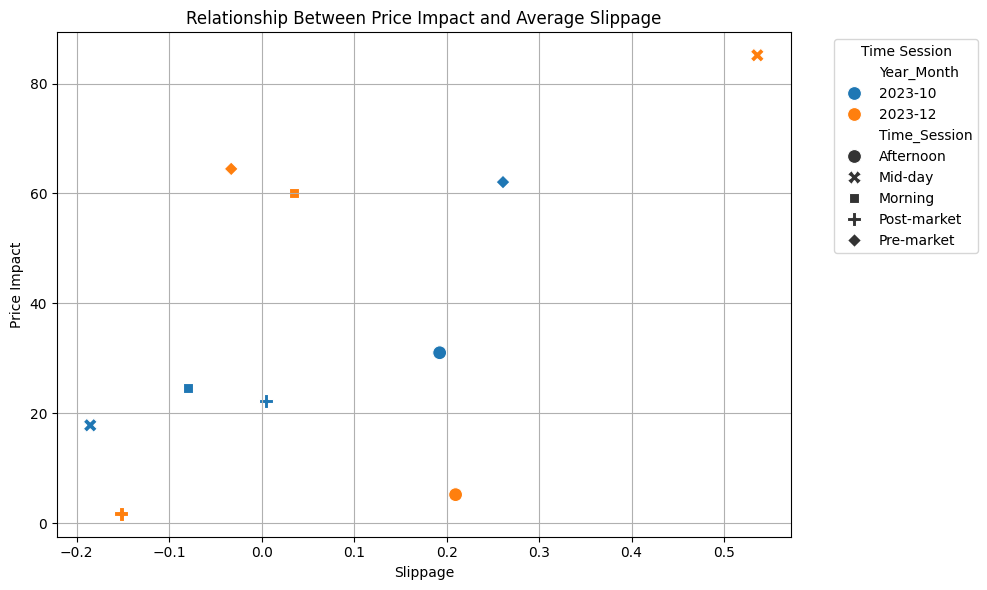

In [324]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes
plt.figure(figsize=(10, 6))

# Scatter plot of Total Signed Volume vs. Price Impact
sns.scatterplot(
    data=final_table.reset_index(),
    x="Volume_Weighted_Slippage",
    y="Price_Impact",
    hue="Year_Month",  # Color by month for differentiation
    style="Time_Session",  # Different marker style for each time session
    s=100  # Set marker size
)

# Adding labels and title
plt.xlabel("Slippage")
plt.ylabel("Price Impact")
plt.title("Relationship Between Price Impact and Average Slippage")
plt.legend(title="Time Session", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

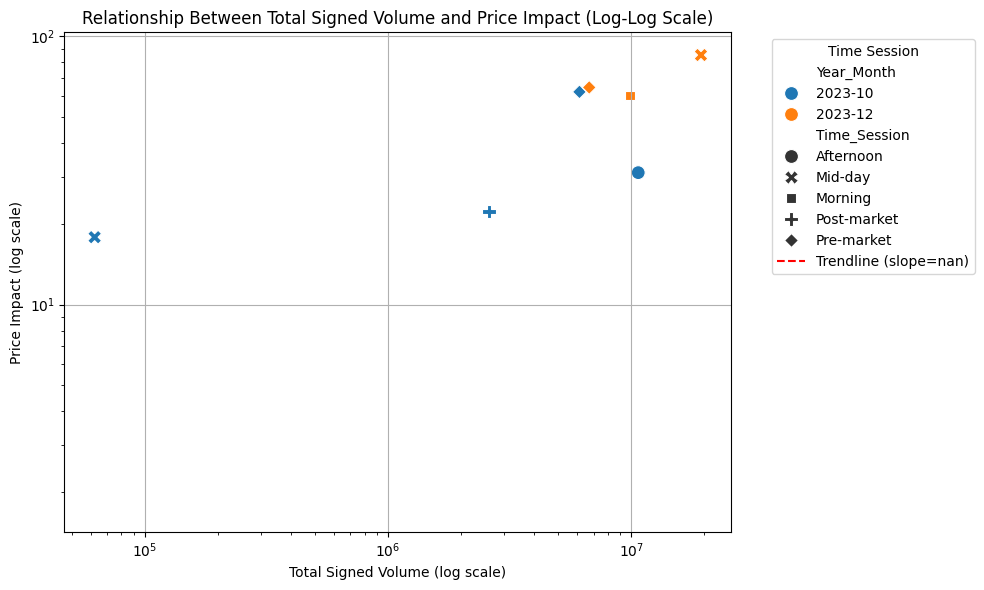

In [325]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Step 1: Drop rows with NaN values in `Total_Signed_Volume` or `Price_Impact`
plot_data = final_table.reset_index()[['Total_Signed_Volume', 'Price_Impact', 'Year_Month', 'Time_Session']].dropna()

# Step 2: Set up the figure and axes with logarithmic x and y scales
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_data,
    x="Total_Signed_Volume",
    y="Price_Impact",
    hue="Year_Month",
    style="Time_Session",
    s=100
)
plt.xscale('log')
plt.yscale('log')  # Logarithmic y-axis for better visualization

# Step 3: Calculate and plot the trendline manually
# Apply log transformation to both x and y for linear regression on log-log scale
log_x = np.log(plot_data['Total_Signed_Volume'])
log_y = np.log(plot_data['Price_Impact'])
slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)

# Generate points for the trendline
x_vals = np.linspace(plot_data['Total_Signed_Volume'].min(), plot_data['Total_Signed_Volume'].max(), 100)
y_vals = np.exp(intercept) * x_vals ** slope  # Transform back from log scale

# Plot the trendline
plt.plot(x_vals, y_vals, color="red", linestyle="--", label=f"Trendline (slope={slope:.2f})")

# Adding labels and title
plt.xlabel("Total Signed Volume (log scale)")
plt.ylabel("Price Impact (log scale)")
plt.title("Relationship Between Total Signed Volume and Price Impact (Log-Log Scale)")
plt.legend(title="Time Session", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

In [326]:
final_table.columns

Index(['Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume',
       'Price_Impact', 'Upper_Limited_Volume', 'Volume_Weighted_Slippage',
       'Dealer_Count'],
      dtype='object')

# first 3 weeks and last week

## Dashboard 2

In [388]:
import pandas as pd

# Step 1: Define Year_Month, Week_Group, and Time_Session in `group1`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
group1['Time_Session'] = group1.index.map(assign_time_session)
group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']
group1['ACCEPTED_Volume'] = group1['ACCEPTEDVOL']

# Step 2: Calculate metrics for each Year_Month and Week_Group
# Calculate Volume Weighted Slippage
volume_weighted_slippage = group1.groupby(['Year_Month', 'Week_Group']).apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage')

# Calculate Notional Value
notional_value = group1.groupby(['Year_Month', 'Week_Group'])['Notional_Value'].sum().rename('Notional_Value')

# Calculate Dealer Count (unique dealers per Year_Month and Week_Group)
dealer_count = group1.groupby(['Year_Month', 'Week_Group'])['DEALER'].nunique().rename('Dealer_Count')

total_volume = group1.groupby(['Year_Month', 'Week_Group'])['ACCEPTED_Volume'].sum().rename('Total_Accepted_Volume')


# Combine metrics into a single DataFrame
combined_data = pd.DataFrame({
    'Volume_Weighted_Slippage': volume_weighted_slippage,
    'Notional_Value': notional_value,
    'Dealer_Count': dealer_count,
    'Total_Accepted_Volume': total_volume

}).reset_index()

# Step 3: Process `df_it` for Signed Volume Weighted Price Impact with week grouping
df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]
df_oct_dec['Time_Session'] = df_oct_dec.index.map(assign_time_session)
df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['I_t']  # Use `I_t` directly
df_oct_dec['Upper_Limited_Volume'] = df_oct_dec['Optimal_Q_t']
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M').astype(str)
df_oct_dec['Week_Group'] = df_oct_dec.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')

# Group by Year_Month and Week_Group for session-based metrics
session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Week_Group']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Total_Signed_Volume_Weighted_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
    Upper_Limited_Volume = ('Upper_Limited_Volume', 'mean')
)

# Calculate Average Price Impact
session_metrics_monthly['Average_Price_Impact'] = session_metrics_monthly['Total_Signed_Volume_Weighted_Impact']

# Reset index for merging compatibility
session_metrics_monthly = session_metrics_monthly.reset_index()

# Step 4: Merge session metrics with combined_data on Year_Month and Week_Group
final_table = session_metrics_monthly.merge(combined_data, on=['Year_Month', 'Week_Group'], how='left')

final_table.set_index(['Year_Month', 'Week_Group'], inplace=True)

final_table = final_table[['Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume', 'Average_Price_Impact','Upper_Limited_Volume', 'Volume_Weighted_Slippage', 'Dealer_Count']]

final_table

Notional_Value  Total_Signed_Volume  \
Year_Month Week_Group                                           
2023-10    First_3_Weeks    3.777889e+09           8769431.05   
           Last_Week        5.046313e+09          10159299.12   
2023-12    First_3_Weeks    6.085540e+09           8037826.44   
           Last_Week        4.466480e+09          25052173.32   

                          Total_Accepted_Volume  Average_Price_Impact  \
Year_Month Week_Group                                                   
2023-10    First_3_Weeks            37778885.37             33.321103   
           Last_Week                50463128.94              9.883061   
2023-12    First_3_Weeks            60855402.74             21.621853   
           Last_Week                44664795.70            124.306245   

                          Upper_Limited_Volume  Volume_Weighted_Slippage  \
Year_Month Week_Group                                                      
2023-10    First_3_Weeks          1.436483e+09                 -0.171703   
           Last_Week              1.651216e+09                  0.283221   
2023-12    First_3_Weeks          1.857331e+09                 -0.084219   
           Last_Week              1.314277e+09                  0.512092   

                          Dealer_Count  
Year_Month Week_Group                   
2023-10    First_3_Weeks            21  
           Last_Week                22  
2023-12    First_3_Weeks            24  
           Last_Week                20

In [389]:
# Specify the path where you want to save the file
file_path = '/content/first3_week_last_week.csv'

# Save the DataFrame to a CSV file
final_table.to_csv(file_path)

In [ ]:
|# group1['MID'] = (group1['COMP_BID'] + group1['COMP_ASK']) / 2
# group1['Slippage_bps'] = group1.apply(calculate_slippage, axis=1)
# group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 10 * 100  # Calculate notional value

# group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
# group1['Year_Month'] = group1.index.to_period('M')  # Year-Month for grouping

# group1['Time_Session'] = group1.index.map(assign_time_session)

# group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL'] * 10

# volume_weighted_slippage = group1.groupby(['Year_Month', 'Time_Session', 'Week_Group']).apply(
#     lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum() * 10)
# ).rename('Volume_Weighted_Slippage')

# notional_value = group1.groupby(['Year_Month', 'Time_Session', 'Week_Group'])['Notional_Value'].sum().rename('Notional_Value')

# combined_data = pd.DataFrame({'Volume_Weighted_Slippage': volume_weighted_slippage, 'Notional_Value': notional_value}).reset_index()

# df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]
# df_oct_dec['Time_Session'] = df_oct_dec.index.map(assign_time_session)
# df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['SIGNED_VOLUME'] * df_oct_dec['I_t']
# df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M')
# df_oct_dec['Week_Group'] = df_oct_dec.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')


# session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Time_Session', 'Week_Group']).agg(
#     Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
#     Total_Signed_Volume_Weighted_Impact=('Signed_Volume_Weighted_Impact', 'sum')
# )

# session_metrics_monthly['Signed_Volume_Weighted_Price_Impact'] = (
#     session_metrics_monthly['Total_Signed_Volume_Weighted_Impact'] / session_metrics_monthly['Total_Signed_Volume'].abs()
# )

# # Reset index
# session_metrics_monthly = session_metrics_monthly.reset_index()

# session_metrics_monthly['Year_Month'] = session_metrics_monthly['Year_Month'].astype(str)
# combined_data['Year_Month'] = combined_data['Year_Month'].astype(str)

# # Merge
# final_table = session_metrics_monthly.merge(
#     combined_data, on=['Year_Month', 'Time_Session', 'Week_Group'], how='left'
# )

# final_table.set_index(['Year_Month', 'Time_Session', 'Week_Group'], inplace=True)

# final_table

Total_Signed_Volume  \
Year_Month Time_Session Week_Group                           
2023-10    Afternoon    First_3_Weeks            674530.52   
                        Last_Week              10009525.21   
           Mid-day      First_3_Weeks            212226.25   
                        Last_Week               -150116.30   
           Morning      First_3_Weeks           -707083.83   
                        Last_Week                169674.95   
           Post-market  First_3_Weeks           4008904.12   
                        Last_Week              -1413074.84   
           Pre-market   First_3_Weeks           4580853.99   
                        Last_Week               1543290.10   
2023-12    Afternoon    First_3_Weeks          -2742787.31   
                        Last_Week                563913.30   
           Mid-day      First_3_Weeks           2176433.85   
                        Last_Week              17180403.00   
           Morning      First_3_Weeks           6452899.09   
                        Last_Week               3408716.67   
           Post-market  First_3_Weeks          -1193435.19   
                        Last_Week                528129.00   
           Pre-market   First_3_Weeks           3344716.00   
                        Last_Week               3371011.35   

                                       Total_Signed_Volume_Weighted_Impact  \
Year_Month Time_Session Week_Group                                           
2023-10    Afternoon    First_3_Weeks                         2.021023e+09   
                        Last_Week                             6.737488e+10   
           Mid-day      First_3_Weeks                         9.294397e+06   
                        Last_Week                             1.009902e+08   
           Morning      First_3_Weeks                         3.490970e+09   
                        Last_Week                             9.090911e+08   
           Post-market  First_3_Weeks                         1.124243e+10   
                        Last_Week                             9.652693e+09   
           Pre-market   First_3_Weeks                         5.184580e+09   
                        Last_Week                             3.796789e+08   
2023-12    Afternoon    First_3_Weeks                         1.951181e+10   
                        Last_Week                             2.852683e+08   
           Mid-day      First_3_Weeks                         3.253211e+09   
                        Last_Week                             1.207257e+11   
           Morning      First_3_Weeks                         1.606460e+10   
                        Last_Week                             1.840197e+10   
           Post-market  First_3_Weeks                         1.516549e+10   
                        Last_Week                             7.330328e+08   
           Pre-market   First_3_Weeks                         1.159040e+10   
                        Last_Week                             5.906261e+09   

                                       Signed_Volume_Weighted_Price_Impact  \
Year_Month Time_Session Week_Group                                           
2023-10    Afternoon    First_3_Weeks                          2996.191444   
                        Last_Week                              6731.076620   
           Mid-day      First_3_Weeks                            43.794755   
                        Last_Week                               672.746528   
           Morning      First_3_Weeks                          4937.137915   
                        Last_Week                              5357.839009   
           Post-market  First_3_Weeks                          2804.365027   
                        Last_Week                              6830.985131   
           Pre-market   First_3_Weeks                          1131.793346   
                        Last_Week                               246.019145   
2023-12    Afternoon 

# Dealers

## Dashboard 3

In [404]:
import pandas as pd

# Assuming `group1` and `df_it` contain the required columns and that `I_t` represents price impact.

# Step 1: Define necessary columns in `group1`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
group1['Time_Session'] = group1.index.map(assign_time_session)
group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']

# Separate data for October and December
oct_data = group1[group1['Year_Month'] == '2023-10'].copy()
dec_data = group1[group1['Year_Month'] == '2023-12'].copy()

# Ensure `I_t` and `Optimal_Q_t` are available for `Price_Impact` calculation by joining with `df_it`
# Reset indices to prepare for the join operation based on the actual index values
oct_data = oct_data.reset_index().set_index(oct_data.index)
dec_data = dec_data.reset_index().set_index(dec_data.index)

# Join `I_t` and `Optimal_Q_t` values from `df_it` based on the original index
oct_data = oct_data.join(df_it[['I_t', 'Optimal_Q_t']], how='left', rsuffix='_impact')
dec_data = dec_data.join(df_it[['I_t', 'Optimal_Q_t']], how='left', rsuffix='_impact')

# Step 2: Calculate metrics, including Price Impact for each dealer
def calculate_metrics(df):
    # Assume that `I_t` represents price impact, use directly for average calculation
    df['Price_Impact'] = df['I_t']
    df['Upper_Limited_Volume'] = df['Optimal_Q_t']

    metrics = df.groupby('DEALER').agg(
        Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
        Total_Accepted_Volume=('ACCEPTEDVOL', 'sum'),
        Notional_Value=('Notional_Value', 'sum'),
        Weighted_Volume_Slippage=('Weighted_Slippage', lambda x: x.sum() / df['ACCEPTEDVOL'].abs().sum()),
        Average_Price_Impact=('Price_Impact', 'mean'),
        Upper_Limited_Volume=('Upper_Limited_Volume', 'mean')  # Add this line to include `Upper_Limited_Volume`
    ).reset_index()
    return metrics

# Calculate metrics for October and December
oct_dealer_metrics = calculate_metrics(oct_data)
dec_dealer_metrics = calculate_metrics(dec_data)

# Step 3: Rank dealers by Total_Accepted_Volume for top and bottom performers

# For October
top_5_dealers_oct = oct_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=False).head(5)
bottom_5_dealers_oct = oct_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=True).head(5)

# For December
top_5_dealers_dec = dec_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=False).head(5)
bottom_5_dealers_dec = dec_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=True).head(5)

# Step 4: Combine top 5 and bottom 5 dealers for both October and December into a single table

# Add a Month column for clarity in the combined table
top_5_dealers_oct['Month'] = 'October'
bottom_5_dealers_oct['Month'] = 'October'
top_5_dealers_dec['Month'] = 'December'
bottom_5_dealers_dec['Month'] = 'December'

# Concatenate all tables into a single DataFrame
combined_top_bottom = pd.concat([
    top_5_dealers_oct, bottom_5_dealers_oct,
    top_5_dealers_dec, bottom_5_dealers_dec
])

# Add a Rank column to indicate top or bottom dealers
combined_top_bottom['Rank'] = ['Top 5'] * 5 + ['Bottom 5'] * 5 + ['Top 5'] * 5 + ['Bottom 5'] * 5

# Step 5: Display the final combined table
print("Combined Top and Bottom 5 Dealers in October and December:")
print(combined_top_bottom[['Month', 'Rank', 'DEALER', 'Total_Signed_Volume', 'Total_Accepted_Volume', 'Notional_Value', 'Weighted_Volume_Slippage', 'Upper_Limited_Volume', 'Average_Price_Impact']])

Combined Top and Bottom 5 Dealers in October and December:
       Month      Rank DEALER  Total_Signed_Volume  Total_Accepted_Volume  \
11   October     Top 5    D50           9806213.22            49608450.78   
2    October     Top 5    D28           9794282.09            41889882.31   
18   October     Top 5     D7           9147509.40            33760179.20   
22   October     Top 5    D74          -5342319.25            25533390.85   
12   October     Top 5    D54          -1127101.42            21003881.22   
7    October  Bottom 5    D37              1878.60                1878.60   
4    October  Bottom 5    D30             -2242.20                2242.20   
23   October  Bottom 5    D79             -5050.00                5050.00   
15   October  Bottom 5    D61            -98980.00              103020.00   
5    October  Bottom 5    D31            110090.00              110090.00   
4   December     Top 5    D28            558716.85            34901524.65   
15  December     

In [408]:
import pandas as pd
import numpy as np

# Assuming `group1` and `df_it` contain the required columns and that `I_t` represents price impact.

# Step 1: Define necessary columns in `group1`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
group1['Time_Session'] = group1.index.map(assign_time_session)
group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']

# Separate data for October and December
oct_data = group1[group1['Year_Month'] == '2023-10'].copy()
dec_data = group1[group1['Year_Month'] == '2023-12'].copy()

# Ensure `I_t` and `Optimal_Q_t` are available for calculations by joining with `df_it`
# Reset indices to prepare for the join operation based on the actual index values
oct_data = oct_data.reset_index().set_index(oct_data.index)
dec_data = dec_data.reset_index().set_index(dec_data.index)

# Join `I_t` and `Optimal_Q_t` values from `df_it` based on the original index
oct_data = oct_data.join(df_it[['I_t', 'Optimal_Q_t']], how='left')
dec_data = dec_data.join(df_it[['I_t', 'Optimal_Q_t']], how='left')

# Step 2: Calculate metrics, including Price Impact and Optimal Volume for each dealer
def calculate_metrics(df):
    # Assume that `I_t` represents price impact, use directly for average calculation
    df['Price_Impact'] = df['I_t']
    df['Optimal_Volume'] = df['Optimal_Q_t']

    metrics = df.groupby('DEALER').agg(
        Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
        Total_Accepted_Volume=('ACCEPTEDVOL', 'sum'),
        Notional_Value=('Notional_Value', 'sum'),
        Weighted_Volume_Slippage=('Weighted_Slippage', lambda x: x.sum() / (df['ACCEPTEDVOL'].abs().sum())),
        Average_Price_Impact=('Price_Impact', 'mean'),
        Upper_Limit_Volume=('Optimal_Volume', 'sum')  # Calculate average optimal volume for each dealer
    ).reset_index()
    return metrics

# Calculate metrics for October and December
oct_dealer_metrics = calculate_metrics(oct_data)
dec_dealer_metrics = calculate_metrics(dec_data)

# Step 3: Rank dealers by Total_Accepted_Volume for top and bottom performers

# For October
top_5_dealers_oct = oct_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=False).head(5)
bottom_5_dealers_oct = oct_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=True).head(5)

# For December
top_5_dealers_dec = dec_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=False).head(5)
bottom_5_dealers_dec = dec_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=True).head(5)

# Step 4: Combine top 5 and bottom 5 dealers for both October and December into a single table

# Add a Month column for clarity in the combined table
top_5_dealers_oct['Month'] = 'October'
bottom_5_dealers_oct['Month'] = 'October'
top_5_dealers_dec['Month'] = 'December'
bottom_5_dealers_dec['Month'] = 'December'

# Concatenate all tables into a single DataFrame
combined_top_bottom = pd.concat([
    top_5_dealers_oct, bottom_5_dealers_oct,
    top_5_dealers_dec, bottom_5_dealers_dec
])

# Add a Rank column to indicate top or bottom dealers
combined_top_bottom['Rank'] = ['Top 5'] * 5 + ['Bottom 5'] * 5 + ['Top 5'] * 5 + ['Bottom 5'] * 5

# Step 5: Display the final combined table with Average Optimal Volume
print("Combined Top and Bottom 5 Dealers in October and December:")
print(combined_top_bottom[['Month', 'Rank', 'DEALER', 'Total_Signed_Volume', 'Total_Accepted_Volume', 'Notional_Value', 'Weighted_Volume_Slippage', 'Average_Price_Impact', 'Upper_Limit_Volume']])


Combined Top and Bottom 5 Dealers in October and December:
       Month      Rank DEALER  Total_Signed_Volume  Total_Accepted_Volume  \
11   October     Top 5    D50           9806213.22            49608450.78   
2    October     Top 5    D28           9794282.09            41889882.31   
18   October     Top 5     D7           9147509.40            33760179.20   
22   October     Top 5    D74          -5342319.25            25533390.85   
12   October     Top 5    D54          -1127101.42            21003881.22   
7    October  Bottom 5    D37              1878.60                1878.60   
4    October  Bottom 5    D30             -2242.20                2242.20   
23   October  Bottom 5    D79             -5050.00                5050.00   
15   October  Bottom 5    D61            -98980.00              103020.00   
5    October  Bottom 5    D31            110090.00              110090.00   
4   December     Top 5    D28            558716.85            34901524.65   
15  December     

In [409]:
combined_top_bottom

,DEALER,Total_Signed_Volume,Total_Accepted_Volume,Notional_Value,Weighted_Volume_Slippage,Average_Price_Impact,Upper_Limit_Volume,Month,Rank
11,D50,9806213.22,49608450.78,4.960845e+09,2.399867e-02,24.864223,1.672883e+09,October,Top 5
2,D28,9794282.09,41889882.31,4.188988e+09,8.072633e-03,39.929094,1.619745e+09,October,Top 5
18,D7,9147509.40,33760179.20,3.376018e+09,1.376817e-03,44.461782,4.921952e+08,October,Top 5
22,D74,-5342319.25,25533390.85,2.553339e+09,1.377350e-03,23.772918,1.370065e+09,October,Top 5
12,D54,-1127101.42,21003881.22,2.100388e+09,2.679214e-02,14.567666,1.081450e+09,October,Top 5
7,D37,1878.60,1878.60,1.878600e+05,-4.058201e-06,32.470526,7.344688e+05,October,Bottom 5
4,D30,-2242.20,2242.20,2.242200e+05,-8.690625e-06,-18.151405,6.949824e+05,October,Bottom 5
23,D79,-5050.00,5050.00,5.050000e+05,2.824622e-07,-154.153566,1.355385e+06,October,Bottom 5
15,D61,-98980.00,103020.00,1.030200e+07,1.099459e-03,126.451429,3.177539e+06,October,Bottom 5
5,D31,110090.00,110090.00,1.100900e+07,7.748814e-05,259.654557,2.776056e+06,October,Bottom 5


In [410]:
# Set Month and Rank as the index for better organization
combined_top_bottom.set_index(['Month', 'Rank'], inplace=True)

# Display the final table with Month and Rank as indices
combined_top_bottom = combined_top_bottom[['DEALER', 'Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume', 'Average_Price_Impact', 'Weighted_Volume_Slippage', 'Upper_Limit_Volume']]
combined_top_bottom

DEALER  Notional_Value  Total_Signed_Volume  \
Month    Rank                                                   
October  Top 5       D50    4.960845e+09           9806213.22   
         Top 5       D28    4.188988e+09           9794282.09   
         Top 5        D7    3.376018e+09           9147509.40   
         Top 5       D74    2.553339e+09          -5342319.25   
         Top 5       D54    2.100388e+09          -1127101.42   
         Bottom 5    D37    1.878600e+05              1878.60   
         Bottom 5    D30    2.242200e+05             -2242.20   
         Bottom 5    D79    5.050000e+05             -5050.00   
         Bottom 5    D61    1.030200e+07            -98980.00   
         Bottom 5    D31    1.100900e+07            110090.00   
December Top 5       D28    3.490152e+09            558716.85   
         Top 5       D54    3.188175e+09           1102320.06   
         Top 5       D50    3.050810e+09          14834993.12   
         Top 5       D63    2.972278e+09           4892399.60   
         Top 5       D74    2.044730e+09            634308.28   
         Bottom 5     D8    2.525000e+04               252.50   
         Bottom 5    D24    2.020000e+06             20200.00   
         Bottom 5    D31    3.030000e+06            -30300.00   
         Bottom 5     D1    3.535000e+06             35350.00   
         Bottom 5    D72    8.289070e+06            -58388.10   

                   Total_Accepted_Volume  Average_Price_Impact  \
Month    Rank                                                    
October  Top 5               49608450.78             24.864223   
         Top 5               41889882.31             39.929094   
         Top 5               33760179.20             44.461782   
         Top 5               25533390.85             23.772918   
         Top 5               21003881.22             14.567666   
         Bottom 5                1878.60             32.470526   
         Bottom 5                2242.20            -18.151405   
         Bottom 5                5050.00           -154.153566   
         Bottom 5              103020.00            126.451429   
         Bottom 5              110090.00            259.654557   
December Top 5               34901524.65             28.635153   
         Top 5               31881754.94             29.891757   
         Top 5               30508102.42             30.158302   
         Top 5               29722785.00             35.825094   
         Top 5               20447296.48             31.108028   
         Bottom 5                 252.50             35.647235   
         Bottom 5               20200.00             54.245381   
         Bottom 5               30300.00             -0.711017   
         Bottom 5               35350.00             37.708768   
         Bottom 5               82890.70              2.400783   

                   Weighted_Volume_Slippage  Upper_Limit_Volume  
Month    Rank                                                    
October  Top 5                 2.399867e-02        1.672883e+09  
         Top 5                 8.072633e-03        1.619745e+09  
         Top 5                 1.376817e-03        4.921952e+08  
         Top 5                 1.377350e-03        1.370065e+09  
         Top 5                 2.679214e-02        1.081450e+09  
         Bottom 5             -4.058201e-06        7.344688e+05  
         Bottom 5             -8.690625e-06        6.949824e+05  
         Bottom 5              2.824622e-07        1.355385e+06  
         Bottom 5              1.099459e-03        3.177539e+06  
         Bottom 5              7.748814e-05        2.776056e+06  
December Top 5                -2.798670e-02        1.440753e+09  
         Top 5                 6.044299e-02        1.001184e+09  
         Top 5                 1.849234e-02        4.791648e+08  
         Top 5                -8.783422e-02        1.183882e+09  
         Top 5                -5.399049e-03        1.119930e+09  
         Bot

In [412]:
# Specify the path where you want to save the file
file_path = '/content/dealers.csv'

# Save the DataFrame to a CSV file
combined_top_bottom.to_csv(file_path)